# Titanic Survival Analysis: Predicting Life and Death at Sea


---

## 1. Project Overview
This project undertakes a comprehensive analysis of the classic **Titanic dataset**, which contains demographic and travel information for passengers aboard the ship during its tragic maiden voyage in 1912. The primary objective is to explore the dataset to understand the factors that influenced a passenger’s chance of survival following the ship’s sinking.

### 1.1. Objectives
Our analysis will begin with a thorough **Exploratory Data Analysis (EDA)**. During this phase, we will investigate the relationships between various passenger features and the ultimate survival outcome. Key predictors to be explored include:
*   **Passenger Class (Pclass)**
*   **Sex**
*   **Age**
*   **Fare**

### 1.2. Key Questions
We aim to identify the key predictors of survival and quantify the strength and nature of their correlations. For instance, we seek to answer:
1.  Did passengers in a higher class have a significantly better chance of survival?
2.  How critical was gender in determining who survived?
3.  What role did age play, especially for children and the elderly?

### 1.3. Tools & Libraries
To conduct this analysis and create insightful visualizations, we will leverage core Python libraries:
*   **Pandas:** For data manipulation and cleaning.
*   **Matplotlib & Seaborn:** For generating clear and informative plots.
*   **Scikit-Learn:** (For the modeling phase).

Ultimately, the insights gained from the EDA will serve as the foundation for building a **predictive machine learning model** capable of accurately classifying whether a passenger would have survived based on their individual characteristics.

---

## 2. Environment Setup & Data Loading
*In this section, we import the necessary libraries and load the dataset into our environment.*


In [2]:
import joblib
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import streamlit as st
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


  ### I load the "Titanic-Dataset.csv" dataset into the application.


In [3]:
Data = pd.read_csv("/Users/amirhjzt/Programing/Machine learning IMT/DataSets/Third/Titanic-Dataset.csv")

###   I convert the dataset into a DataFrame for exploratory data analysis (EDA).


In [4]:
Df = pd.DataFrame(Data)

---

  ### To view and understand the DataFrame, I use these commands.


In [5]:
Df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


---



### 📖 Data Dictionary

Below is the detailed description of the features available in the Titanic dataset (`Titanic-Dataset.csv`):

| Feature | Description | Key / Notes |
| :--- | :--- | :--- |
| **`PassengerId`** | Unique identifier for each passenger | - |
| **`Survived`** | Survival status (Target Variable) | `0` = No, `1` = Yes |
| **`Pclass`** | Ticket class (Proxy for socio-economic status) | `1` = 1st (Upper)<br>`2` = 2nd (Middle)<br>`3` = 3rd (Lower) |
| **`Name`** | Full name of the passenger | Includes titles (e.g., Mr., Mrs., Miss) |
| **`Sex`** | Gender of the passenger | `male` or `female` |
| **`Age`** | Age in years | Fractional if less than 1. Often contains missing values. |
| **`SibSp`** | Number of siblings or spouses aboard | Sibling = brother, sister, stepbrother, stepsister<br>Spouse = husband, wife |
| **`Parch`** | Number of parents or children aboard | Parent = mother, father<br>Child = daughter, son, stepdaughter, stepson |
| **`Ticket`** | Ticket number | Alphanumeric |
| **`Fare`** | Passenger fare | Price paid for the ticket |
| **`Cabin`** | Cabin number | Often contains a high percentage of missing values. |
| **`Embarked`** | Port of Embarkation | `C` = Cherbourg<br>`Q` = Queenstown<br>`S` = Southampton |

---

###  To see the DataFrame info I use this command . 

In [6]:
Df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


---

<b>

## 🧹  Identifying and Handling Duplicates

The very first step in our data cleaning pipeline is to ensure our dataset does not contain duplicate records. Duplicates can introduce **bias** into our machine learning models, distort our statistical analysis, and cause **data leakage**.

**🔍 Types of Duplicates to Check:**

*   **Full-Row Duplicates:** Rows where every single column matches another row perfectly. These are usually the result of data entry errors or faulty data collection and **must be removed**.
*   **Subset Duplicates (e.g., ID columns):** Rows that share a unique identifier (like `PassengerId`). A unique ID should only appear once in the dataset.

**🚢 Titanic Dataset Specifics:**
In this dataset, a full-row duplicate is highly unlikely due to the unique `PassengerId` and `Name` columns. However, checking programmatically is a standard best practice. 


Let's check for any duplicate rows using pandas `.duplicated()` method.


<b>

In [7]:
Duplicate_Count = Df.duplicated().sum()

print(f"Number of duplicated data in dataset is {Duplicate_Count}")

Number of duplicated data in dataset is 0


In [8]:
Cols_To_Ignore = ["PassengerId", "Name"]

Duplicated_Columns = [col for col in Df.columns if col not in Cols_To_Ignore]

Duplicated_Rows = Df[Df.duplicated(subset=Duplicated_Columns, keep=False)]

display(Duplicated_Rows)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
65,66,1,3,"Moubarek, Master. Gerios",male,NaN,1,1,2661,15.2458,NaN,C
74,75,1,3,"Bing, Mr. Lee",male,32.00,0,0,1601,56.4958,NaN,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.5500,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.5500,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.5500,NaN,S
229,230,0,3,"Lefebre, Miss. Mathilde",female,NaN,3,1,4133,25.4667,NaN,S
241,242,1,3,"Murphy, Miss. Katherine ""Kate""",female,NaN,1,0,367230,15.5000,NaN,Q
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0000,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.5500,NaN,S
369,370,1,1,"Aubart, Mme. Leontine Pauline",female,24.00,0,0,PC 17477,69.3000,B35,C


### 📌 Conclusion: Are These True Duplicates?

After temporarily ignoring unique identifiers (`PassengerId` and `Name`), the `.duplicated()` method flagged several rows. However, a closer inspection reveals that these are **not actual duplicates**, but rather distinct passengers who happen to share identical features.

**Why did this happen?**
1. **Family Members:** Siblings or children from the same family (e.g., the *Sage* or *Lefebre* families) share the same `Pclass`, `Ticket`, `Fare`, `SibSp`, and `Parch`. When their `Age` is missing (`NaN`), their records become identical.
2. **Traveling Companions:** Individuals traveling together (like a lady and her maid, or two workers) might share the same cabin, ticket, and fare. If they share the same age and gender, they appear identical without their names.

**✅ Action Taken:**
Since every single row represents a unique historical passenger, **no rows will be dropped**. The Titanic dataset is free of true duplicate records, and we can safely proceed to the next preprocessing steps.


<b>

---

<b>

## Noise Detection

The next crucial step in our preprocessing pipeline is identifying and managing **Noise** in our dataset. Noisy data—such as erroneous entries, logically impossible values, or inconsistent formatting—can heavily mislead machine learning models and compromise the integrity of our analysis.

**🎯 Strategy based on Feature Types:**

*   **Categorical Features** (`Survived`, `Pclass`, `Sex`, `Embarked`, `Has_Cabin`): 
    Since these are discrete variables with fixed, defined classes, noise typically manifests as invalid categories, typos, or inconsistent case usage (e.g., a `Pclass` of `4` or a `Sex` labeled as `Male` instead of `male`). We will validate these columns against a predefined dictionary of expected, valid values.
    
*   **Numerical Features** (`Fare`, `Age`, `SibSp`, `Parch`): 
    For numerical columns, noise refers to logically impossible or unphysical values rather than statistical extremes (e.g., a negative `Age` or a negative `Fare`). We will investigate these columns using strict domain boundary checks and logical constraints (e.g., $Age \ge 0$).
    
*   **Text/Identifier Features** (`Name`, `Ticket`, `PassengerId`): 
    These are unstructured strings or unique identifiers. Noise here might include corrupted characters, accidental whitespace, or inconsistent string formatting, but standard logical boundary validation is not directly applicable to them.


<b>

### Noise Detection and Definition in Titanic Dataset Columns

In this section, we define the rules for identifying incorrect or invalid data entries (noise) for each column. Any data falling outside these boundaries is considered noise and requires correction:

| Column Name | Valid & Logical Values | Noise Definition (Invalid Data) |
| :--- | :--- | :--- |
| **`Survived`** | $0$ or $1$ | Any value other than $0$ and $1$ |
| **`Pclass`** | $1$, $2$, or $3$ | Any value other than $1$, $2$, or $3$ |
| **`Sex`** | `male` = 0 or `female` = 1 | Any value other than `male` = 0 or `female` = 1 |
| **`Age`** | $0$ to $125$ years | Any number less than $0$ (negative) or greater than $125$ |
| **`SibSp` & `Parch`**| Numbers $\ge 0$ | Any number less than $0$ (negative) |
| **`Fare`** | Numbers $\ge 0$ | Any number less than $0$ (negative) |
| **`Embarked`** | `C`, `Q`, or `S` | Any value other than `C`, `Q`, or `S` |


##### We calculate the Survived, Pclass, Sex, Has_Cabin, Embarked  noise with the following method.



In [9]:
Valid_Dict = {

    "Survived" : [0, 1],
    "Pclass" : [1, 2, 3],
    "Sex" : [1, 0], 
    "Embarked" : ['C', 'Q', 'S']

}



for Feature, Value_Dict in Valid_Dict.items() : 

    if Feature in Df.columns : 
        

        Noise_Count = (~Df[Feature].isin(Value_Dict)).sum()

        print(f"The count of noise in {Feature} is {Noise_Count}")

The count of noise in Survived is 0
The count of noise in Pclass is 0
The count of noise in Sex is 891
The count of noise in Embarked is 2


##### We calculate the Age noise with the following method.



In [10]:
Noise_Age_Count = (~Df['Age'].between(0, 125)).sum()

print(Noise_Age_Count)

177


##### We calculate the Fare noise with the following method.



In [11]:
Noise_Fare_Count = (Df['Fare'] < 0).sum()
print(Noise_Fare_Count)


0


##### We calculate the SibSp noise with the following method.



In [12]:
Noise_SibSp_Count = (Df['SibSp'] < 0).sum()

print(Noise_SibSp_Count)

0


##### We calculate the Parch noise with the following method.



In [13]:
Noise_Parch_Count = (Df['Parch'] < 0).sum()

print(Noise_Parch_Count)

0


###  Conclusion on Noise Detection

After inspecting the numerical and categorical features (such as `Age`, `Fare`, and `Parch`), **no impossible or illogical values (noise) were found** in the dataset. 

The data is structurally valid, and we can safely proceed to the next step: **Handling Missing Values**.


<b>

---

<b>

### 🔍 Handling Missing Values

**What are Missing Values?**
Missing values refer to data points that are unrecorded or incomplete within a dataset. These missing entries can be represented in various forms, such as `NaN` (Not a Number), `Null`, dashes (`-`), empty strings, or any other symbol indicating incomplete or absent information.

**How to Handle Missing Values:**

Our strategy for dealing with missing values depends on their proportion and distribution:

*   **Column Removal (> 50% missing data):** If more than 50% (or a vast majority) of the data in a specific column is missing, it is often best to drop the column entirely. The reason is that imputing or "fabricating" such a massive volume of missing data can be highly inaccurate and significantly mislead the machine learning model.
*   **Imputation (< 50% missing data):** If the percentage of missing values is lower, we explore whether there is a logical and valid method to fill (impute) them. This can be done using statistical measures like the mean, median, mode (most frequent value), or even predictive modeling based on other features.
*   **Row Removal:** In certain situations, we may decide to completely drop rows (records) containing missing values (especially critical ones). This approach is usually taken when the number of such rows is a very small or negligible fraction of the entire dataset.


<b>

### Counting Missing Values

At first, I will use the below method to count the number of missing values in each column. Identifying the exact count of missing data is the essential first step before deciding whether to drop or impute values.



In [14]:
for i in Df.columns : 

    Count_Of_missing_values = Df[i].isna().sum()

    if Count_Of_missing_values != 0 : 
        
        print(f"Number of missing values in {i} is {Df[i].isna().sum()}")

Number of missing values in Age is 177
Number of missing values in Cabin is 687
Number of missing values in Embarked is 2


<b>

### 📌 Checking for Simultaneous Missing Values

In this section, we want to investigate whether there are any overlapping or simultaneous missing values across different features. By checking pairs of columns, we can determine if a missing value in one column is associated with a missing value in another, which helps us decide on the best imputation strategy.


In [15]:
for i in Df.columns: 
    for a in Df.columns: 
        if i != a: 
            Count_of_same_missing_values = (Df[i].isna() & Df[a].isna()).sum()
            

            if Count_of_same_missing_values != 0: 
                print(f"Number of same missing values between {a} and {i} is {Count_of_same_missing_values}")

Number of same missing values between Cabin and Age is 158
Number of same missing values between Age and Cabin is 158


<b>

### 🗑️ Dropping Missing Values in 'Embarked'

Since the `Embarked` column contains only a very small number of missing values, we decided to simply drop those specific rows from our dataset. This allows us to keep the data clean without losing a significant amount of information.


In [16]:
Df.dropna(subset=["Embarked"], inplace=True)

<b>

## But also we have "Age " and "Cabin" same and diffrent missing values so we need to manage them . 

<b>

### 🧠 Advanced Imputation: Handling Missing Values in the 'Age' Feature

**Observation:**
Upon evaluating our dataset, we identified exactly **175 missing values** in the `Age` column. Because `Age` is widely recognized as a critical predictive feature in this context (e.g., historical "children first" survival policies), handling these missing values correctly is paramount.

**The Challenge:**
* **Dropping Rows:** Simply removing 175 rows would result in a massive loss of valuable data and potentially introduce bias.
* **Simple Imputation:** Filling the missing data with a global mean or median is a univariate approach. It is too simplistic, ignores the underlying patterns in the data, and artificially reduces the variance of the feature.

**Our Strategy: K-Nearest Neighbors (KNN) Imputation**
To resolve this, we will use a **KNN Imputer**, which is a robust, multivariate machine learning approach. 

**How it Works & Why We Chose It:**
Instead of looking at the `Age` column in isolation, the KNN model analyzes the entire dataset to find patterns. For every passenger with a missing `Age`, the algorithm calculates their mathematical "distance" to all other passengers based on other available features (such as `Pclass`, `Fare`, `Sex`, `SibSp`, etc.). 

It then selects the $K$ most similar passengers (the "nearest neighbors") and estimates the missing age by averaging the ages of those specific neighbors. 

**Conclusion:**
By utilizing KNN imputation, we ensure that our estimated ages are context-aware, highly personalized, and mathematically justified by the surrounding data, thereby preserving the complex relationships within our dataset for future modeling.


In [17]:
Imputer = KNNImputer(n_neighbors=2)

In [18]:
Cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

In [19]:
Df_imputed = Imputer.fit_transform(Df[Cols])

In [20]:
Df[Cols] = Df_imputed

In [21]:
Df_imputed = pd.DataFrame(Df_imputed, columns=Cols)


<b>

### 🛠 Strategy for Handling Missing Values in the `Cabin` Feature

From a statistical perspective, when the percentage of missing values in a feature exceeds a certain threshold, the most straightforward and common approach is to simply **drop** the entire column. 

**However, there is an exception:**
In certain situations, we can extract valuable insights by investigating the underlying relationship between these missing values and other features. Therefore, before discarding the `Cabin` column, we first need to analyze whether there is a correlation between the missing cabin data and other variables in the dataset. 

**Our Approach:**
If a meaningful pattern exists, we might be able to use the "missingness" itself as a valuable piece of information. Instead of treating the missing values as just lost data, we can engineer a new feature that categorizes passengers into two groups:
* **Data Recorded:** Passengers with a known cabin.
* **Data Missing:** Passengers without cabin information. 

By doing this, the absence of data becomes a new, potentially powerful feature for our model.


<b>

### 🔍 Uncovering Hidden Relationships: Analyzing the `Cabin` Column

Now that we have decided to transform the presence or absence of a cabin into a meaningful feature, the next step is to **prove this hypothesis**. We need to investigate whether having a cabin is associated with other passenger information. 

To uncover these relationships, we can simultaneously use two approaches: **statistical analysis** and **data visualization**. However, before we begin, we must consider a crucial point: **the nature and type of our variables are not uniform.** 

Our dataset contains different types of data, and we must adopt a specific strategy to analyze each:

1. **Continuous Numeric Data:** Such as `Fare` and `Age`.
> *🛠 **Approach:** For these variables, we will use a **Correlation Matrix** for statistical analysis and plots like **Boxplots** or **KDEs** to observe differences in distributions.*

2. **Discrete Numeric Data:** Such as `Pclass`, `SibSp`, and `Parch`.
> *🛠 **Approach:** Given the limited distinct values of these variables, using cross-tabulations and **Countplots** is a more suitable approach to understanding their relationships.*

3. **Categorical / Object Data:** Such as `Sex` and `Embarked`.
> *🛠 **Approach:** Since we cannot apply standard mathematical correlation methods to non-numeric data, we will utilize **Groupby** techniques, calculate mean percentages, and use **Barplots** to compare different categories.*

Moving forward, keeping these differences in mind, we will systematically analyze the relationship between our new `Has_Cabin` variable and the rest of the dataset.


<b>

*Data Summary:* Using the `describe()` function to get a general overview of the dataset, which helps in identifying potential relationships between the `Cabin` feature and other variables.

In [22]:
Df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,30.063183,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,14.032097,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<b>

1. **Continuous Numeric Data:** Such as `Fare` and `Age`.
> *🛠 **Approach:** For these variables, we will use a **Correlation Matrix** for statistical analysis and plots like **Boxplots** or **KDEs** to observe differences in distributions.*


In [23]:
Df['Has_Cabin'] = Df['Cabin'].notna().astype(int)

numeric_df = Df.select_dtypes(include=['number'])

correlations = numeric_df.corr()['Has_Cabin'].sort_values(ascending=False)


print("Correlation with Has_Cabin:")
print(correlations)


Correlation with Has_Cabin:
Has_Cabin      1.000000
Fare           0.480425
Survived       0.313435
Age            0.238864
Parch          0.039101
PassengerId    0.020045
SibSp         -0.038657
Pclass        -0.723815
Name: Has_Cabin, dtype: float64


<b>

### 💡 Key Insights: The Relationship Between Cabin, Fare, and Ticket Class

Based on our analysis, we can clearly see that having a recorded cabin is strongly tied to a passenger's socioeconomic status. 

* **Direct Relationship with `Fare`:** There is a clear positive correlation here. Passengers who paid higher ticket fares were significantly more likely to have a cabin assigned to them.
* **Inverse (but logical) Relationship with `Pclass`:** Mathematically, having a cabin shows a negative/inverse correlation with `Pclass`. However, logically, this makes perfect sense. The numerical value of `Pclass` is inversely related to its actual prestige (i.e., `1` represents the highest, most luxurious class, while `3` is the lowest). Therefore, higher-class passengers are the ones who typically have cabins.

**🎯 Conclusion:**
Although both `Fare` and `Pclass` essentially represent the same underlying factor (the passenger's purchasing power and status), **we will prioritize `Pclass`**. Because `Pclass` is already a well-defined ordinal category (pre-grouped), it is a much cleaner, simpler, and more robust feature to work with compared to the continuous values of `Fare`.


<b>

 <h4><b>Statistical Shortcut 💡</b></h4>
    Using <code>.mean()</code> on a binary column (0/1) is a powerful shortcut to find the percentage of positive cases (1s) within a group.
</div>

In [24]:
Binary_feature = ['Survived', 'Sex', 'Embarked', 'Pclass']

for col in Binary_feature : 

    print(f"Analysis for Column:   {col}")

    Precentage = Df.groupby(col)['Has_Cabin'].mean()*100

    print(Precentage)
    print("\n")

Analysis for Column:   Survived
Survived
0.0    12.386157
1.0    39.411765
Name: Has_Cabin, dtype: float64


Analysis for Column:   Sex
Sex
female    30.448718
male      18.544194
Name: Has_Cabin, dtype: float64


Analysis for Column:   Embarked
Embarked
C    41.071429
Q     5.194805
S    20.031056
Name: Has_Cabin, dtype: float64


Analysis for Column:   Pclass
Pclass
1.0    81.308411
2.0     8.695652
3.0     2.443992
Name: Has_Cabin, dtype: float64




<b>

### Key Insight: `Pclass` and Cabin Allocation

As the analysis shows, **`Pclass`** has the strongest relationship with having a cabin. Passengers in First Class were significantly more likely to have a registered cabin number, with a rate of nearly **80%**.

<b>

<div >
    <h4><b>Our Analysis Strategy 🎯</b></h4>
    To reach a definitive conclusion, we will combine statistical data with visualizations. This dual approach provides both <b>numerical proof</b> and <b>intuitive understanding</b> of the <code>Cabin</code> feature's relationships.
</div>


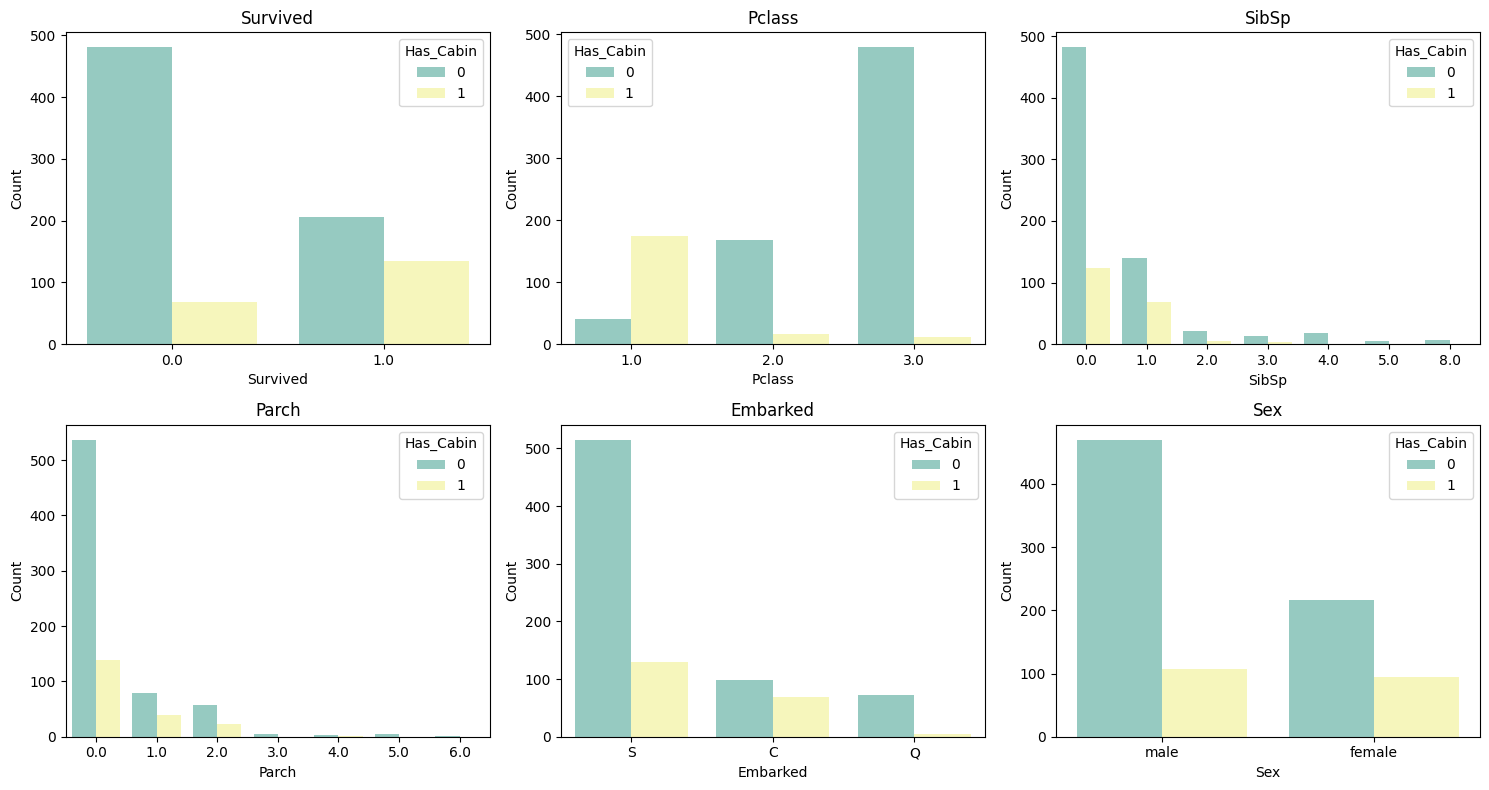

In [25]:
Cols_Bar_plot = ['Survived', 'Pclass', 'SibSp', 'Parch', 'Embarked', 'Sex']

plt.figure(figsize=(15, 8))

counter = 1 

for i in Cols_Bar_plot: 
    plt.subplot(2, 3, counter)
    
    sns.countplot(data=Df, x=i, hue='Has_Cabin', palette='Set3')
    
    plt.title(f'Count of {i} grouped by Has_Cabin')
    plt.ylabel('Count')
    
    plt.title(f'{i}')
    counter += 1

plt.tight_layout()
plt.show()

<b>

### 📌 Conclusion: Transforming the Cabin Feature

Based on both statistical data and visual analysis, it is evident that the **`Pclass`** feature has the strongest relationship with the presence of a cabin. Passengers in higher classes are significantly more likely to have a recorded cabin. 

**Action Taken:** Given this strong correlation and the high number of missing values, we have decided to transform the original `Cabin` column into a new binary feature called **`Has_Cabin`** (1 = Has Cabin, 0 = No Cabin) to preserve this valuable information for our model.


In [26]:
Df.drop(columns=['Cabin'], inplace=True)

---

In [27]:
Df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    float64
 2   Pclass       889 non-null    float64
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    float64
 7   Parch        889 non-null    float64
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
 11  Has_Cabin    889 non-null    int64  
dtypes: float64(6), int64(2), str(4)
memory usage: 124.9 KB


---

<b>

### 🚨 Outlier Detection & Handling

**Outliers** are data points that differ significantly from other observations in a dataset, exhibiting anomalous behavior.

#### ⚠️ Why is Checking for Outliers Important?
The presence of outliers can have a severe negative impact on the machine learning pipeline:
* **Model Skewing & Distortion:** Outliers can drastically alter weights, slopes, and overall model parameters (especially in distance-based or sensitive algorithms like Linear Regression, KNN, and SVM), pulling the model's trajectory toward themselves.
* **Performance Degradation:** If not properly identified and handled, the model can suffer from high bias, leading to a significant drop in accuracy and overall efficiency.

#### 🛠️ Common Detection Methods:
To identify outliers, we typically use the following statistical and visual tools:
1. **Interquartile Range (IQR):** Establishing lower and upper bounds based on data distribution.
2. **Z-Score:** Measuring the distance of a data point from the mean in terms of standard deviation.
3. **Visualizations:** Utilizing Boxplots and Scatter Plots to easily spot anomalies.

🎯 **In this section, we will investigate the outliers in our dataset.** Once identified, we will decide on the best strategy: whether to drop them, apply capping/clipping, or retain them as valuable underlying patterns.


<b>

# Outlier Detection Using Box Plots

The Box Plot (or box-and-whisker plot) is a powerful visualization tool for understanding the distribution of numerical data and identifying potential outliers. It graphically depicts data through its quartiles.

## Components of a Box Plot:

1.  **The Box:** Represents the central 50% of the data.
    -   **Bottom Edge (Q1):** The first quartile (25th percentile).
    -   **Middle Line (Q2):** The median (50th percentile).
    -   **Top Edge (Q3):** The third quartile (75th percentile).

2.  **Interquartile Range ($IQR$):** The distance between the first and third quartiles, which represents the length of the box.
    $$IQR = Q3 - Q1$$

3.  **The Whiskers:** These lines extend from the box to show the range of the data that is considered "normal".
    -   **Lower Bound:** $Q1 - (1.5 \times IQR)$
    -   **Upper Bound:** $Q3 + (1.5 \times IQR)$

4.  **Outliers:** Any data point that falls outside the whiskers (either below the lower bound or above the upper bound) is flagged as a potential outlier. These are typically plotted as individual points.

---
**Interpretive Note:** Seeing many points beyond the whiskers, as is common in skewed features like `Fare` in the Titanic dataset, indicates a skewed distribution. It's crucial to investigate whether these outliers are data errors or legitimate, rare occurrences before deciding to remove or transform them.


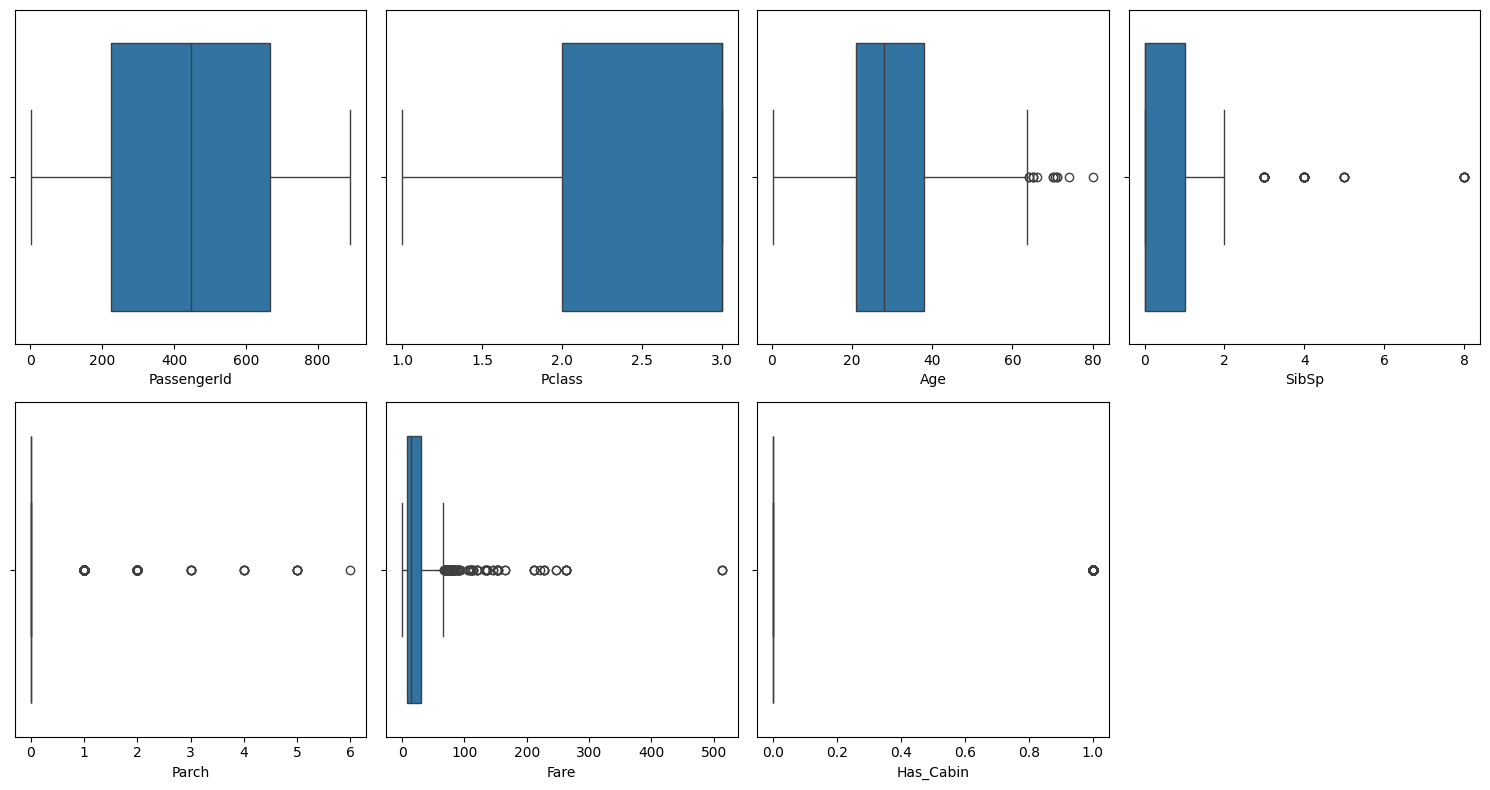

In [28]:
Numeric_cols = Df.select_dtypes(include=['int64', 'float']).columns

plt.figure(figsize=(15, 8))

counter = 1 



for i in Numeric_cols : 
    if i != 'Survived':
            plt.subplot(2, 4, counter)
            sns.boxplot(data=Df, x=i)
            counter += 1

plt.tight_layout()
plt.show()

### Conclusion: Boxplot Analysis
* **Purpose:** Provides a standardized way of displaying the distribution of data based on a five-number summary: minimum, first quartile ($Q1$), median, third quartile ($Q3$), and maximum.
* **Key Insights:** 
    * **Outliers:** Easily identifies anomalies as individual data points plotted outside the "whiskers" (typically values < $Q1 - 1.5 \times IQR$ or > $Q3 + 1.5 \times IQR$).
    * **Spread and Skewness:** The length of the box represents the Interquartile Range ($IQR$), showing where the middle 50% of the data lies. The position of the median line inside the box indicates potential skewness.
* **Best Use Case:** Highly effective for detecting strict statistical outliers and comparing data distributions across different categorical groups side-by-side.


<b>

<b>

# Identifying Outliers Using a Histogram

A histogram is a powerful graphical tool for visualizing the frequency distribution of a numerical variable. By dividing the data into equal intervals (bins) and counting the number of observations in each bin, this chart allows us to understand the overall shape of the data distribution.

## How Does a Histogram Help Identify Outliers?

1.  **Shape of the Distribution:** By looking at a histogram, we can quickly determine if the data has a normal (bell-shaped) distribution or if it is skewed to the right or left.

2.  **Identifying Outliers:** Outliers typically appear as isolated bars far from the main cluster of data. In skewed distributions, these data points create a long "tail" on one side of the chart. These tails indicate the presence of values that are either much larger (right skew) or much smaller (left skew) compared to the rest of the data.

---
**Interpretive Note:** A histogram by itself does not define a precise boundary for what constitutes an outlier (unlike a box plot), but it clearly shows their presence and direction. For example, in the Titanic dataset, the histogram for the `Fare` column shows a strong right skew, indicating a small number of passengers with very high fares. This chart serves as an excellent complement to a box plot to provide a more complete understanding of the data distribution.


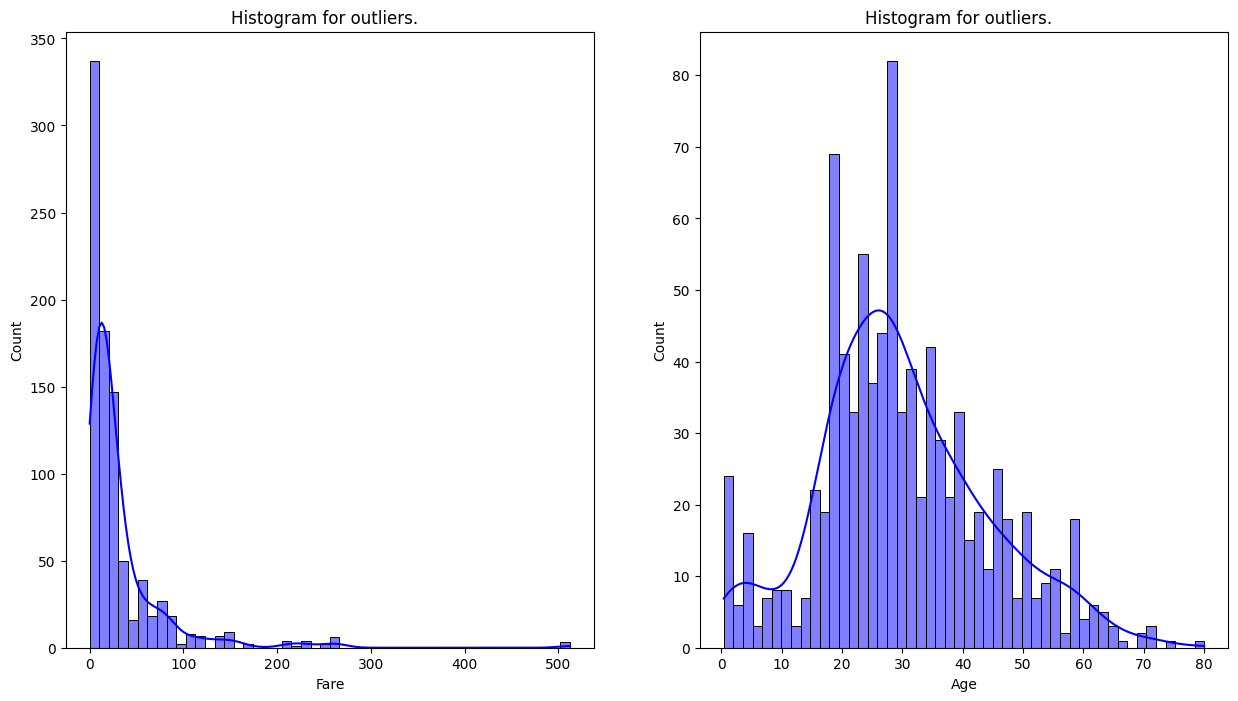

In [29]:
Hist_Plot_Count = ["Fare", "Age"]

plt.figure(figsize=(15, 8))

counter = 1 



for i in Hist_Plot_Count : 
    if i != 'Survived':
            plt.subplot(1, 2, counter)

            sns.histplot(data=Df, x=i, bins=50, kde=True, color='blue')
            counter += 1

            plt.title("Histogram for outliers.  ")
            plt.xlabel(i)
            plt.ylabel('Count')


plt.show()

### Conclusion: Histogram Analysis
* **Purpose:** Visualizes the frequency distribution of continuous numerical data by grouping values into continuous intervals or "bins".
* **Key Insights:**
    * **Shape and Distribution:** Quickly reveals the underlying distribution of the data (e.g., normal, right-skewed, left-skewed, or bimodal).
    * **Central Tendency:** The highest peaks (tallest bars) clearly show where the most common values congregate.
    * **Gaps and Extreme Values:** Highlights isolated bars or long tails, which helps in visually spotting potential outliers and understanding the limits of the data.
* **Best Use Case:** Ideal as the very first step in univariate analysis to grasp the overall shape, density, and general behavior of a single feature.


<b>

### Statistical Outlier Detection Methods

Statistical methods rely on the mathematical properties of the data distribution to identify extreme values. The two most common univariate approaches are:

**1. Interquartile Range (IQR) Method**
*   **Concept:** This method is robust to skewed data and does not assume a normal distribution. It focuses on the middle 50% of the data.
*   **Calculation:** 
    *   Calculate the First Quartile ($Q1$, 25th percentile) and Third Quartile ($Q3$, 75th percentile).
    *   Compute the IQR: $IQR = Q3 - Q1$
*   **Outlier Boundaries:** 
    *   Lower Bound: $Q1 - 1.5 \times IQR$
    *   Upper Bound: $Q3 + 1.5 \times IQR$
    *   *Any data point falling outside these boundaries is considered an outlier.*

**2. Z-Score Method**
*   **Concept:** This method measures how many standard deviations a data point is away from the mean. It assumes the data follows a Gaussian (normal) distribution.
*   **Calculation:** 
    *   Formula: $Z = \frac{x - \mu}{\sigma}$ (where $\mu$ is the mean and $\sigma$ is the standard deviation).
*   **Outlier Boundaries:**
    *   Typically, a threshold of $3$ is used.
    *   *If $|Z| > 3$ (i.e., the point is more than 3 standard deviations away from the mean), it is flagged as an outlier.*


In [30]:
Q1 = Df['Fare'].quantile(0.25)
Q3 = Df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

print(f"IQR Lower Bound: {lower_bound_iqr}")
print(f"IQR Upper Bound: {upper_bound_iqr}")

outliers_iqr = Df[(Df['Fare'] < lower_bound_iqr) | (Df['Fare'] > upper_bound_iqr)]
print(f"Number of outliers (IQR): {len(outliers_iqr)}")


IQR Lower Bound: -26.7605
IQR Upper Bound: 65.6563
Number of outliers (IQR): 114


In [31]:
Q1 = Df['Age'].quantile(0.25)
Q3 = Df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

print(f"IQR Lower Bound: {lower_bound_iqr}")
print(f"IQR Upper Bound: {upper_bound_iqr}")

outliers_iqr = Df[(Df['Age'] < lower_bound_iqr) | (Df['Age'] > upper_bound_iqr)]
print(f"Number of outliers (IQR): {len(outliers_iqr)}")

IQR Lower Bound: -4.5
IQR Upper Bound: 63.5
Number of outliers (IQR): 13


In [32]:
mean_fare = Df['Fare'].mean()
std_fare = Df['Fare'].std()

lower_bound_z = mean_fare - (3 * std_fare)
upper_bound_z = mean_fare + (3 * std_fare)

print(f"Z-Score Lower Bound: {lower_bound_z}")
print(f"Z-Score Upper Bound: {upper_bound_z}")

Df['Fare_Zscore'] = (Df['Fare'] - mean_fare) / std_fare
outliers_z = Df[np.abs(Df['Fare_Zscore']) > 3]
print(f"Number of outliers (Z-Score): {len(outliers_z)}")

Z-Score Lower Bound: -116.99583207273355
Z-Score Upper Bound: 181.1891938275142
Number of outliers (Z-Score): 20


In [33]:
mean_Age = Df['Age'].mean()
std_Age = Df['Age'].std()

lower_bound_z = mean_Age - (3 * std_Age)
upper_bound_z = mean_Age + (3 * std_Age)

print(f"Z-Score Lower Bound: {lower_bound_z}")
print(f"Z-Score Upper Bound: {upper_bound_z}")

Df['Age_Zscore'] = (Df['Age'] - mean_fare) / std_Age
outliers_z = Df[np.abs(Df['Age_Zscore']) > 3]
print(f"Number of outliers (Z-Score): {len(outliers_z)}")

Z-Score Lower Bound: -12.033107750248892
Z-Score Upper Bound: 72.15947445441087
Number of outliers (Z-Score): 1


### 📝 Conclusion and Selecting the Optimal Method for Outlier Detection

By comparing the **Z-Score** and **IQR** methods on the `Fare` column, significant differences in the results can be observed:

* ❌ **Ineffectiveness of the Z-Score method:** This method relies on the assumption that the data has a **normal (bell-shaped) distribution**. Since the distribution of the `Fare` column is heavily Right-Skewed, the Z-Score method calculates the Lower Bound as a **negative number**. Given that a ticket price logically cannot be less than zero, the results of this method are invalid for this feature.

* ✅ **Superiority of the IQR method:** The Interquartile Range ($IQR$) method is a non-parametric approach and does not depend on a normal distribution. It is calculated using quartiles and is highly robust against skewed data, providing much more logical boundaries for our dataset.

🎯 **Final Decision:**
Considering the nature of the Titanic dataset and the fact that important numerical columns (like `Fare` and `Age`) do not follow a normal distribution, **the Z-Score method is discarded**. In this project, **the $IQR$ method will be used as the primary and standard approach** for identifying and analyzing outliers.


<b>

### 🛠️ Strategies for Handling Outliers

Now that we have identified the outliers using the **IQR** method, we must decide how to treat them. It is crucial to note that in the Titanic dataset, outliers in features like `Fare` and `Age` represent **valid, natural variations** (e.g., wealthy passengers in First Class or elderly passengers) rather than data entry errors. Therefore, simply dropping these rows would result in the loss of valuable information.

Here are the standard approaches to handle them:

1. ✂️ **Capping / Winsorization:** 
   Instead of removing the outlier rows, we cap the extreme values at a specific threshold (e.g., the Upper Bound of the IQR). This retains the data point but reduces the extreme magnitude.
   
2. 🧮 **Log Transformation (Highly Recommended for `Fare`):** 
   Applying a logarithmic transformation (like $log(x+1)$) is extremely effective for highly right-skewed data like `Fare`. It compresses the extreme values, reduces variance, and makes the distribution closer to a normal curve without losing information.

3. 🌳 **Do Nothing (Algorithm Dependent):** 
   If we plan to use tree-based machine learning models (such as Random Forest, Decision Trees, or XGBoost), we can leave the outliers as they are. These algorithms are robust and inherently insensitive to extreme values.

4. 🗑️ **Removal / Trimming (Not Recommended here):** 
   Deleting the rows entirely. This is generally avoided unless the outlier is proven to be a pure noise/error, as it shrinks the dataset and removes valid scenarios.

**🎯 Strategy for this Project:**
For the `Fare` feature, we will apply **Log Transformation** to handle the heavy skewness smoothly. For `Age`, we will either keep them as they are or use **Capping** to prevent extreme ages from disproportionately affecting distance-based models (like Logistic Regression or KNN).


<b>

### 🧮 Handling `Fare` Outliers: Log Transformation
Because the `Fare` distribution is highly right-skewed and contains extreme values, we will apply a Log Transformation. Since some `Fare` values are exactly 0, we use `np.log1p()` which calculates $log(1 + x)$ to avoid undefined values ($log(0)$). We will store this in a new column called `Fare_log`.


In [34]:
Df['Fare_log'] = np.log1p(Df['Fare'])


<b>

### ✂️ Handling `Age` Outliers: Capping (Winsorization)
For the `Age` column, we will use the IQR method to find the upper boundary. Any age exceeding this upper bound will be capped (replaced) with the boundary value itself. This prevents extreme ages from skewing the model without losing the rows.


In [35]:
Q1_age = Df['Age'].quantile(0.25)
Q3_age = Df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

upper_bound_age = Q3_age + 1.5 * IQR_age
    
Df['Age_capped'] = np.clip(Df['Age'], a_min=None, a_max=upper_bound_age)


<b>

---

In [36]:
Df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    float64
 2   Pclass       889 non-null    float64
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    float64
 7   Parch        889 non-null    float64
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
 11  Has_Cabin    889 non-null    int64  
 12  Fare_Zscore  889 non-null    float64
 13  Age_Zscore   889 non-null    float64
 14  Fare_log     889 non-null    float64
 15  Age_capped   889 non-null    float64
dtypes: float64(10), int64(2), str(4)
memory usage: 152.7 KB


---

##  Feature Engineering

Feature engineering is the process of creating new, meaningful columns from the existing raw data. For the Titanic dataset, this is one of the most crucial steps to improve model performance.

**Examples of Feature Engineering in Titanic:**
*   **Creating Family Size:** Combining the `SibSp` and `Parch` columns to create a new `Family_Size` feature.


<b>

In [37]:
Df["Family_Size"] = Df["SibSp"] + Df["Parch"] + 1

---

In [38]:
Df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Fare_Zscore,Age_Zscore,Fare_log,Age_capped,Family_Size
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,8.890000e+02,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,30.063183,0.524184,0.382452,32.096681,0.227222,1.358743e-16,-0.144918,2.959024,29.984443,1.906637
std,256.998173,0.486260,0.834700,14.032097,1.103705,0.806761,49.697504,0.419273,1.000000e+00,1.000000,0.967750,13.816620,1.614703
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,-6.458409e-01,-2.257445,0.000000,0.420000,1.000000
25%,224.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000,-4.869637e-01,-0.790807,2.185579,21.000000,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,-3.549973e-01,-0.291951,2.737881,28.000000,1.000000
75%,668.000000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,0.000000,-2.206712e-02,0.420701,3.465736,38.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,9.663111e+00,3.413839,6.240917,63.500000,11.000000


---

# Categorical Encoding

## What is Categorical Encoding?
Categorical Encoding is the process of converting categorical data (text labels) into numerical data. Machine learning algorithms are based on mathematical equations, and they can only work with numbers. Therefore, we need to convert columns with text data (like `Sex` or `Embarked`) into a numerical format before we can use them for model training.

## Why is it important?
Models cannot understand text. If we feed a column with values like "Male", "Female", or "S", "C", "Q" directly into a model, it will cause an error. Encoding translates this valuable information into a language the model understands (numbers), allowing it to find patterns.


<b>

In [39]:
Df['Sex'] = Df['Sex'].map({'male' : 0 , "female" : 1})

In [40]:
Df['Embarked'] = Df['Embarked'].map({'C' : 0 , "Q" : 1, 'S' : 2})

---

In [41]:
Df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    float64
 2   Pclass       889 non-null    float64
 3   Name         889 non-null    str    
 4   Sex          889 non-null    int64  
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    float64
 7   Parch        889 non-null    float64
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    int64  
 11  Has_Cabin    889 non-null    int64  
 12  Fare_Zscore  889 non-null    float64
 13  Age_Zscore   889 non-null    float64
 14  Fare_log     889 non-null    float64
 15  Age_capped   889 non-null    float64
 16  Family_Size  889 non-null    float64
dtypes: float64(11), int64(4), str(2)
memory usage: 154.5 KB


___

## Data Scaling (Feature Scaling)

**Data Scaling** is a critical data preprocessing step that involves transforming the values of numeric columns in the dataset to a common scale, without distorting differences in the ranges of values.

### Why is Data Scaling Important?
Many machine learning algorithms (like K-Nearest Neighbors, Support Vector Machines, and Neural Networks) calculate the distance between data points. If features have drastically different ranges (e.g., in the Titanic dataset, `Age` ranges from $0$ to $80$, while `Fare` can go up to $512$), the features with larger magnitudes will dominate the distance calculations. Scaling ensures that every feature contributes equally to the model's predictions.

*(Note: Tree-based algorithms like Random Forest and XGBoost are generally unaffected by the scale of the features).*

### Common Scaling Methods

#### 1. Standardization (Z-Score Scaling)
Standardization transforms the data so that it has a mean ($\mu$) of $0$ and a standard deviation ($\sigma$) of $1$. It does not bound the data to a specific range, which makes it less sensitive to extreme outliers than Min-Max scaling.
*   **Formula:** $z = \frac{x - \mu}{\sigma}$
*   **Scikit-Learn Library:** `StandardScaler`

#### 2. Normalization (Min-Max Scaling)
Normalization rescales the features to a fixed range, usually between $0$ and $1$. It is very useful when the distribution is not Gaussian (normal) or when you need bounded values, but it is highly sensitive to outliers.
*   **Formula:** $x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$
*   **Scikit-Learn Library:** `MinMaxScaler`

#### 3. Robust Scaling
If your data contains significant outliers (like the `Fare` column in the Titanic dataset), standardizing using the mean and standard deviation might skew the results. Robust scaling uses the median and the Interquartile Range (IQR), making it immune to the influence of outliers.
*   **Formula:** $x_{scaled} = \frac{x - \text{Median}}{IQR}$
*   **Scikit-Learn Library:** `RobustScaler`


<b>

In [42]:
num_cols = ['Age', 'Fare']

scaler = StandardScaler()

Df[num_cols] = scaler.fit_transform(Df[num_cols])

display(Df[num_cols].head())


,Age,Fare
0,-0.574948,-0.500240
1,0.565937,0.788947
2,-0.289727,-0.486650
3,0.352021,0.422861
4,0.352021,-0.484133


---

In [43]:
Df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Fare_Zscore,Age_Zscore,Fare_log,Age_capped,Family_Size
count,889.000000,889.000000,889.000000,889.000000,8.890000e+02,889.000000,889.000000,8.890000e+02,889.000000,889.000000,8.890000e+02,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,0.350956,2.158004e-16,0.524184,0.382452,1.398706e-16,1.535433,0.227222,1.358743e-16,-0.144918,2.959024,29.984443,1.906637
std,256.998173,0.486260,0.834700,0.477538,1.000563e+00,1.103705,0.806761,1.000563e+00,0.792088,0.419273,1.000000e+00,1.000000,0.967750,13.816620,1.614703
min,1.000000,0.000000,1.000000,0.000000,-2.113716e+00,0.000000,0.000000,-6.462044e-01,0.000000,0.000000,-6.458409e-01,-2.257445,0.000000,0.420000,1.000000
25%,224.000000,0.000000,2.000000,0.000000,-6.462530e-01,0.000000,0.000000,-4.872378e-01,1.000000,0.000000,-4.869637e-01,-0.790807,2.185579,21.000000,1.000000
50%,446.000000,0.000000,3.000000,0.000000,-1.471159e-01,0.000000,0.000000,-3.551972e-01,2.000000,0.000000,-3.549973e-01,-0.291951,2.737881,28.000000,1.000000
75%,668.000000,1.000000,3.000000,1.000000,5.659371e-01,1.000000,0.000000,-2.207954e-02,2.000000,0.000000,-2.206712e-02,0.420701,3.465736,38.000000,2.000000
max,891.000000,1.000000,3.000000,1.000000,3.560760e+00,8.000000,6.000000,9.668551e+00,2.000000,1.000000,9.663111e+00,3.413839,6.240917,63.500000,11.000000


---

# Feature Selection

## What is Feature Selection?
Feature selection is the process of automatically or manually selecting the most important and relevant features (columns) from the data to be used in building a machine learning model. The main goal is to remove irrelevant, redundant, or noisy features that might harm the model's performance or make it unnecessarily complex.

This process is different from Feature Engineering. In Feature Engineering, we create *new* features, whereas in Feature Selection, we *select* the best ones from the *existing* features.

## Why is Feature Selection important?

1. **Reduces Overfitting:** By removing irrelevant features, the model is less likely to learn noise, which increases its generalization power on new, unseen data.
2. **Improves Model Accuracy:** Sometimes, extra features act as noise and can actually decrease the model's accuracy. Removing them improves performance.
3. **Reduces Training Time:** Training a model on data with fewer dimensions (fewer columns) is significantly faster.
4. **Increases Interpretability:** Understanding and explaining a model with 10 features is much easier and more intuitive than a model with 100 features.


<b>

In [44]:
Df.drop(columns="PassengerId", inplace=True)

In [45]:
Df.drop(columns="Ticket", inplace=True)

In [46]:
Df.drop(columns="Name", inplace=True)

In [47]:
Df.drop(columns="Fare_Zscore", inplace=True)

In [48]:
Df.drop(columns="Age_Zscore", inplace=True)

In [49]:
Df.drop(columns="Fare_log", inplace=True)

In [50]:
Df.drop(columns="Age_capped", inplace=True)

----

In [51]:
Df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     889 non-null    float64
 1   Pclass       889 non-null    float64
 2   Sex          889 non-null    int64  
 3   Age          889 non-null    float64
 4   SibSp        889 non-null    float64
 5   Parch        889 non-null    float64
 6   Fare         889 non-null    float64
 7   Embarked     889 non-null    int64  
 8   Has_Cabin    889 non-null    int64  
 9   Family_Size  889 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 76.4 KB


---


# 📊 Data Visualization 

Data visualization is the graphical representation of information. It acts as a bridge between raw numbers and human understanding, helping us quickly uncover hidden patterns, trends, and anomalies.

### 🌟 Why is it Important?
* **Pattern Recognition:** The human brain processes visuals much faster than tables of raw data.
* **Outlier & Error Detection:** Makes it easy to spot anomalies (e.g., using Box plots).
* **Discovering Relationships:** Reveals correlations between features and the target variable.
* **Data Storytelling:** The most effective way to communicate findings to non-technical stakeholders.


‌<b>

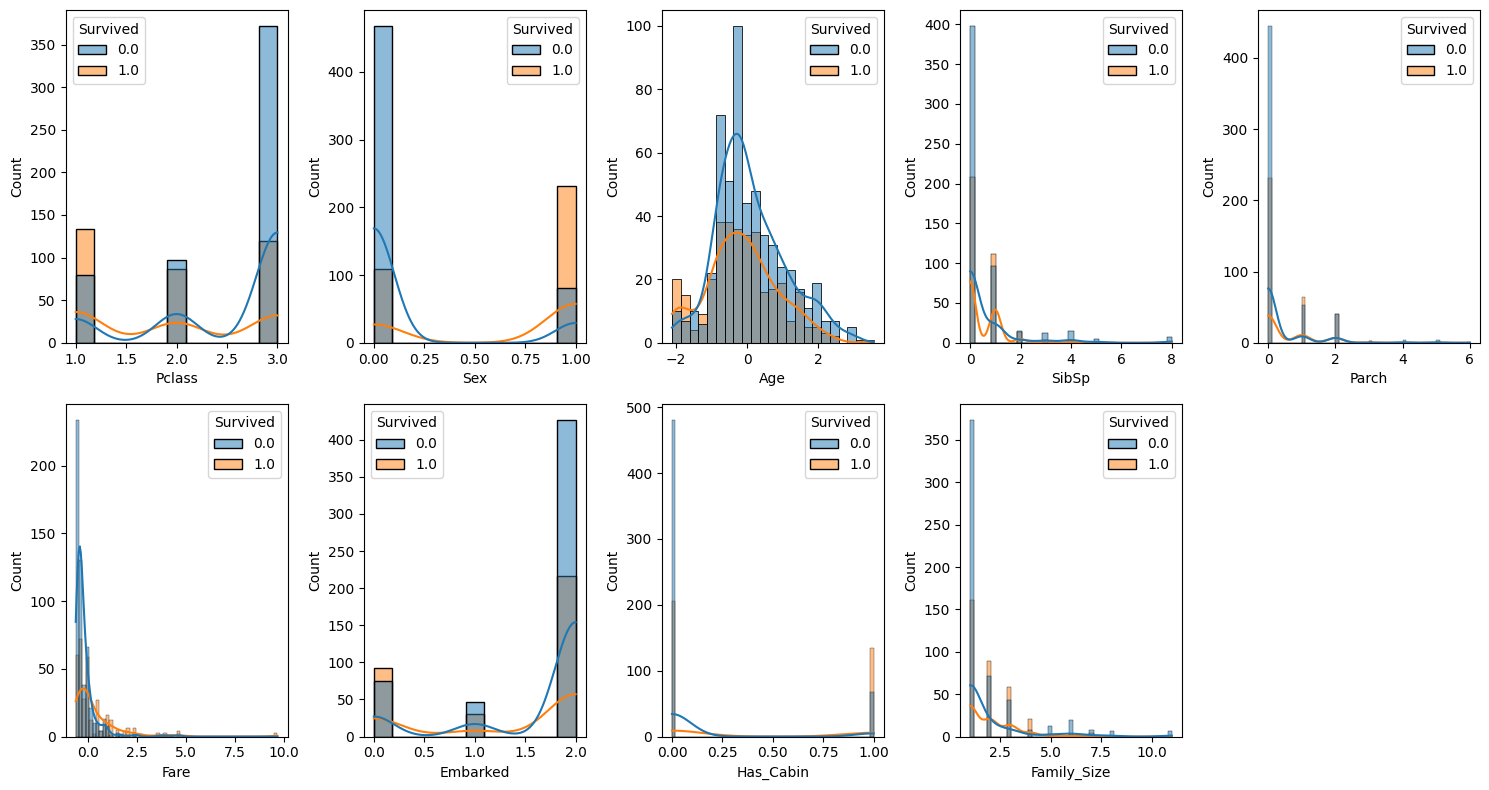

In [52]:
Numeric_cols = Df.select_dtypes(include=['int64', 'float']).columns

plt.figure(figsize=(15, 8))

counter = 1 



for i in Numeric_cols : 
    if i != 'Survived':
            plt.subplot(2, 5, counter)
            sns.histplot(data=Df, x=i, hue="Survived", kde=True)
            counter += 1

plt.tight_layout()
plt.show()

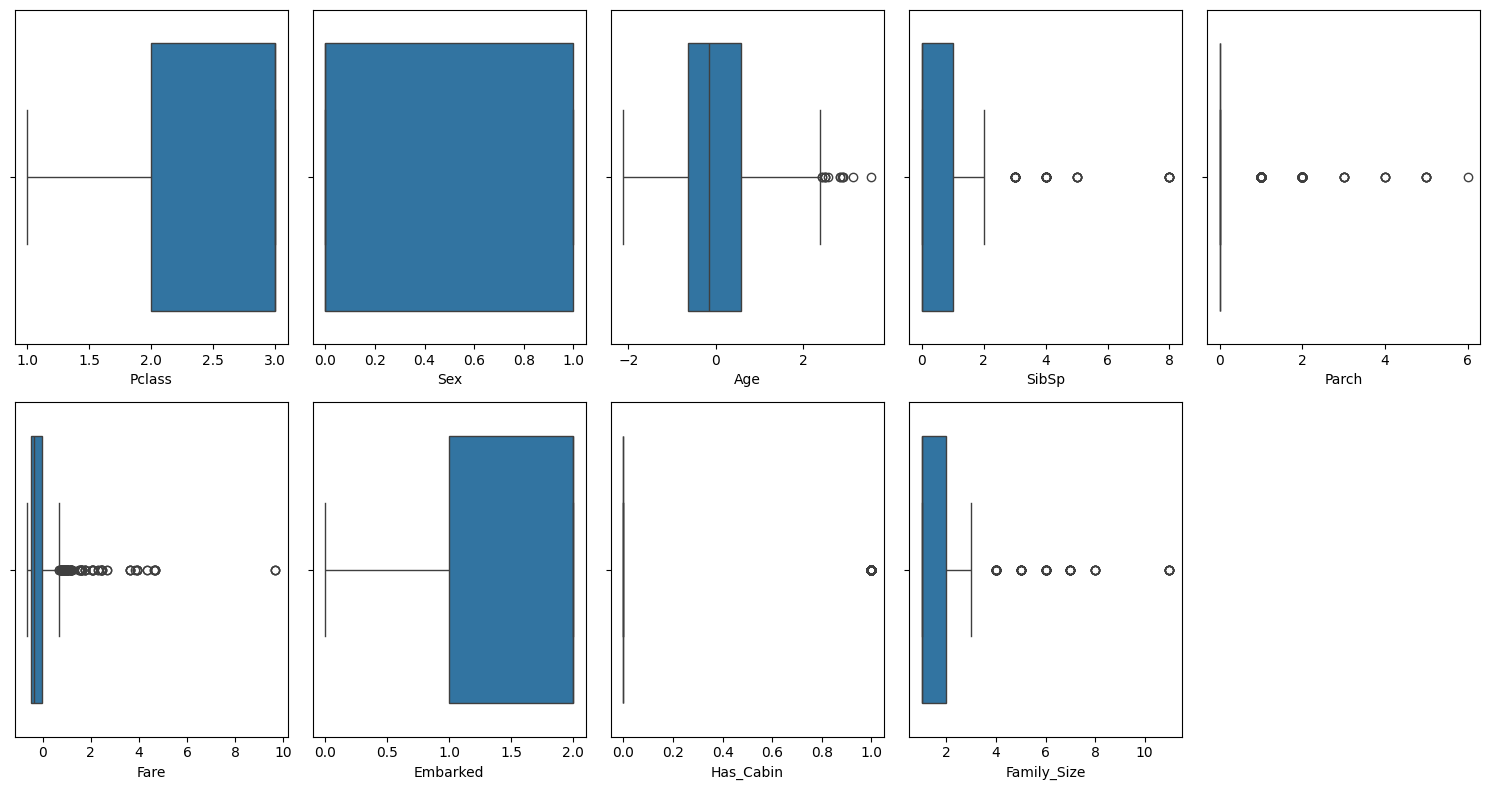

In [53]:
Numeric_cols = Df.select_dtypes(include=['int64', 'float']).columns

plt.figure(figsize=(15, 8))

counter = 1 



for i in Numeric_cols : 
    if i != 'Survived':
            plt.subplot(2, 5, counter)
            sns.boxplot(data=Df, x=i)
            counter += 1

plt.tight_layout()
plt.show()

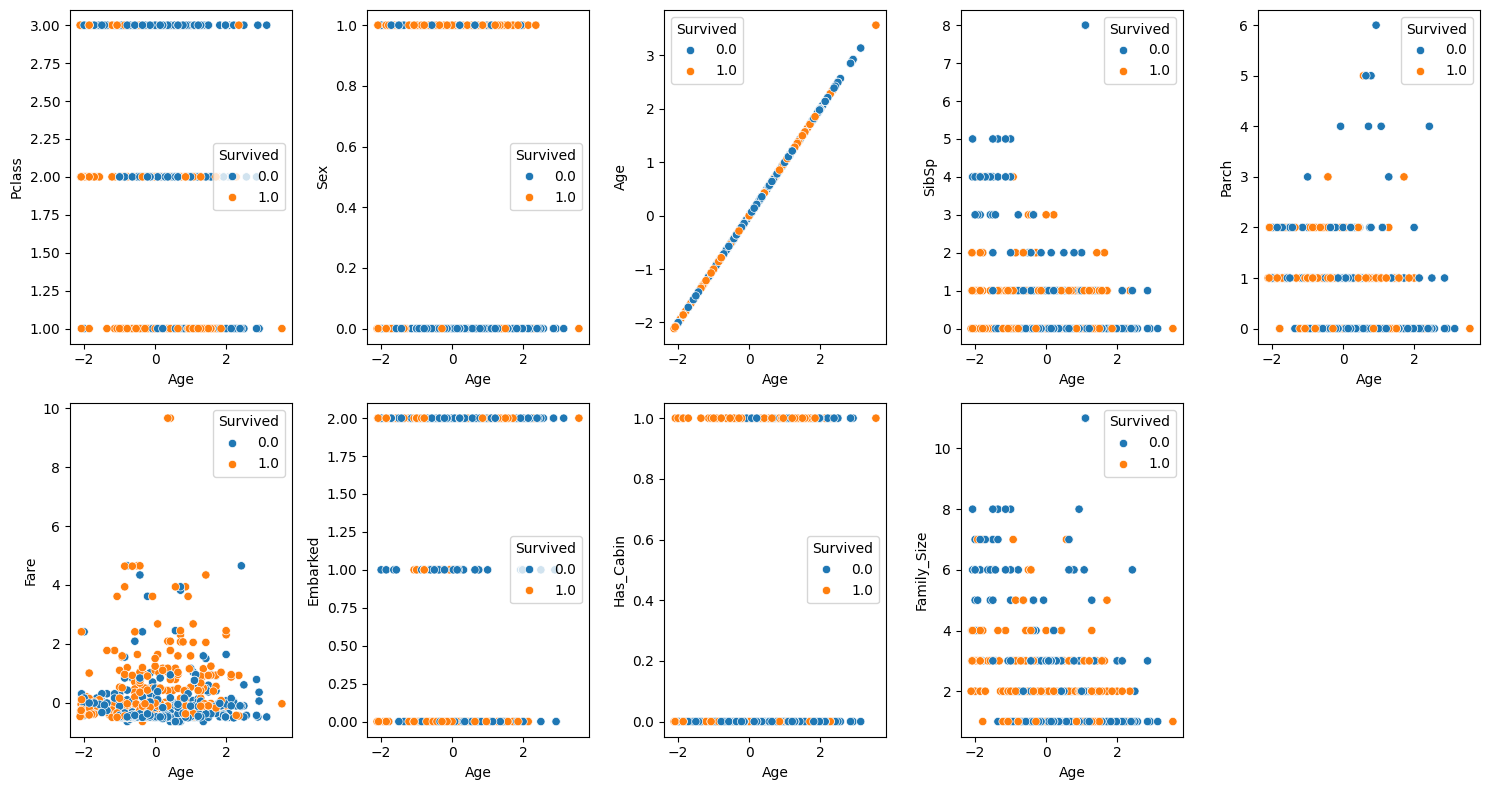

In [54]:
Numeric_cols = Df.select_dtypes(include=['int64', 'float']).columns

plt.figure(figsize=(15, 8))

counter = 1 



for i in Numeric_cols : 
    if i != 'Survived':
            plt.subplot(2, 5, counter)
            sns.scatterplot(data=Df, x='Age',y=i,  hue="Survived")
            counter += 1

plt.tight_layout()
plt.show()

---

# ✂️ Train / Test Split

Before training the machine learning model, we must split the dataset into two separate parts:

* **Training Set (e.g., 80%):** The data used to train the model and let it learn patterns.
* **Testing Set (e.g., 20%):** Unseen data used to evaluate how well the model generalizes to new situations.

**Why?** 
This step is crucial to prevent **overfitting**. It ensures our model doesn't just memorize the training data, but actually learns the underlying patterns to make accurate predictions on real-world data.


<b>

In [55]:
X = Df.drop("Survived",axis=1)

In [56]:
y = Df["Survived"]

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=.2, random_state=42)

In [58]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (711, 9)
X_test shape: (178, 9)


---

## 🤖 Machine Learning & Deployment

In this section, we developed and deployed a predictive model to determine passenger survival using a combination of powerful algorithms.

- **Machine Learning Models:** We trained and evaluated three distinct machine learning models to capture different patterns in the data:
  - **Random Forest**
  - **Logistic Regression**
  - **XGBoost**

- **Ensemble Approach (Voting Classifier):** Instead of relying on a single algorithm, we aggregated the predictions of all three models using a Voting Classifier. This ensemble method combines the strengths and overall results of each individual model to reach a more accurate and robust final conclusion.

- **Deployment:** The final trained model (`titanic_voting_model.pkl`) along with the data scaler (`scaler.pkl`) was deployed as an interactive web dashboard using **Streamlit**. This allows users to input passenger details and get real-time survival predictions.


In [59]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)


In [60]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)


In [61]:
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)


In [62]:
print("--- Single Models Performance ---")
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    model.fit(X_train, Y_train)
    

    y_pred = model.predict(X_test)
    

    acc = accuracy_score(Y_test, y_pred)
    print(f"{name} Accuracy: {acc * 100:.2f}%")

print("\n" + "="*35 + "\n")

--- Single Models Performance ---
Logistic Regression Accuracy: 80.90%
Random Forest Accuracy: 81.46%
XGBoost Accuracy: 83.15%




In [63]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='hard'
)


voting_model.fit(X_train, Y_train)


voting_pred = voting_model.predict(X_test)
voting_acc = accuracy_score(Y_test, voting_pred)

print("--- Ensemble Model Performance ---")
print(f"Voting Classifier Accuracy: {voting_acc * 100:.2f}%")


print("\nDetailed Report for Voting Classifier:")
print(classification_report(Y_test, voting_pred))

--- Ensemble Model Performance ---
Voting Classifier Accuracy: 82.58%

Detailed Report for Voting Classifier:
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.86       109
         1.0       0.77      0.78      0.78        69

    accuracy                           0.83       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178



In [64]:
joblib.dump(voting_model, 'titanic_voting_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']